In [1]:
# Install dependencies
!pip install torch torchvision pillow transformers

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip uninstall -y pinecone-client

In [3]:
!pip install pinecone

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install -qU \
    pinecone==7.0.1 \
    pinecone-notebooks

In [9]:
# Import libraries
from pinecone import Pinecone, ServerlessSpec
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import torch, json, glob

In [6]:
# Import initialize Pinecone and other libraries
# ---- CLIP (image embeddings) ----
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

/voc/work/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2025-08-23 18:16:48.028165: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-23 18:17:21.456811: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-23 18:18:22.733261: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_e

VOC-NOTICE: GPU memory for this assignment is capped at 2048MiB


/voc/work/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [7]:
def get_image_embedding(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        emb = model.get_image_features(**inputs)          # [1, 512]
    emb = emb / emb.norm(p=2, dim=-1, keepdim=True)        # normalize
    return emb.squeeze(0).cpu().numpy().tolist()           # list[512]

In [10]:
# ---- Pinecone v3 client ----
pc = Pinecone(api_key="pcsk_67VPfk_Jg7G1SoTj7yc8jZoK6ryMxmzL8GiA6bwmtp2qHP1MLJ5NYEvT8ixEQwpEttt4Ey")

index_name = "image-index"
dimension = 512  # CLIP ViT-B/32 output size
metric = "cosine"

# create index if it doesn't exist
existing = [i.name for i in pc.list_indexes()]
if index_name not in existing:
    pc.create_index(
        name=index_name,
        dimension=dimension,
        metric=metric,
        spec=ServerlessSpec(cloud="aws", region="us-east-1")  # change region as you like
    )

index = pc.Index(index_name)

In [11]:
# ---- upsert multiple images (e.g., up to 50 from ./images) ----
image_paths = glob.glob("./images/*.jpg")[:50] + glob.glob("./images/*.png")[:50]

vectors = []
for i, p in enumerate(image_paths):
    vec = get_image_embedding(p)
    vectors.append({"id": f"img-{i}", "values": vec, "metadata": {"filename": p}})

# upsert to a namespace (optional)
index.upsert(vectors=vectors, namespace="images")
print(f"Upserted {len(vectors)} vectors.")

Upserted 50 vectors.


In [12]:
# ---- similarity search with a query image ----
query_path = image_paths[0]  # or any other image path
qvec = get_image_embedding(query_path)

res = index.query(
    vector=qvec,
    top_k=3,
    include_metadata=True,
    namespace="images"
)

# pretty print (v3 objects support .to_dict())
print(json.dumps(res.to_dict(), indent=2))

{
  "matches": [],
  "namespace": "images",
  "usage": {
    "read_units": 1
  }
}


In [13]:
# ---- similarity search with a query image ----
query_path = image_paths[6]  # or any other image path
print (query_path)
qvec = get_image_embedding(query_path)

res = index.query(
    vector=qvec,
    top_k=3,
    include_metadata=True,
    namespace="images"
)

# pretty print (v3 objects support .to_dict())
print(json.dumps(res.to_dict(), indent=2))

./images/45.jpg
{
  "matches": [
    {
      "id": "img-6",
      "score": 1.00073242,
      "values": [],
      "metadata": {
        "filename": "./images/45.jpg"
      }
    },
    {
      "id": "img-13",
      "score": 0.715362549,
      "values": [],
      "metadata": {
        "filename": "./images/12.jpg"
      }
    },
    {
      "id": "img-40",
      "score": 0.674179137,
      "values": [],
      "metadata": {
        "filename": "./images/22.jpg"
      }
    }
  ],
  "namespace": "images",
  "usage": {
    "read_units": 1
  }
}


In [14]:
#show both the query image and the top-K retrieved images in a grid with matplotlib.
import matplotlib.pyplot as plt

def show_query_and_results(query_path, results, k=5):
    """
    Display the query image + top-K results from Pinecone in a grid.
    """
    # load query image
    query_img = Image.open(query_path).convert("RGB")
    
    # plot query image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, k+1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # plot retrieved images
    for i, match in enumerate(results['matches'][:k], start=2):
        fname = match['metadata']['filename']
        img = Image.open(fname).convert("RGB")
        plt.subplot(1, k+1, i)
        plt.imshow(img)
        plt.title(f"Score: {match['score']:.2f}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

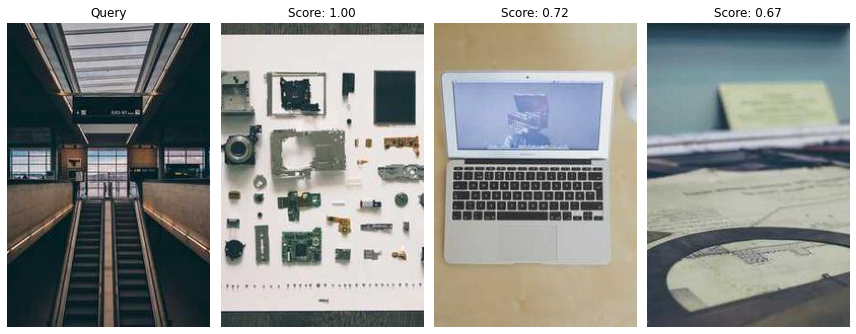

In [15]:
query_path = image_paths[4]  # or any other image path
show_query_and_results(query_path, res.to_dict(), k=3)

In [16]:
pc.delete_index(name=index_name)